### 2026-03-12 temporal variance

Compare temporal variance (here defined as scale of daily anomalies from monthly means) over a year in the AIMIP submissions, compared to ERA5 reference.

In [1]:
import xarray as xr
import numpy as np
import os
from dask.diagnostics import ProgressBar
from cartopy import crs as ccrs
from matplotlib import pyplot as plt

from aimip_data_utils import (
    AIMIP_EXPERIMENT_SUBMISSIONS,
    ExperimentSubmission,
    EVALUATION_VARIABLES,
    open_aimip_data,
    add_latlon_to_dlesym,
    regrid_dataset,
    transfer_attrs,
    convert_tdas_to_huss,
    compute_weighted_mean,
    CATEGORICAL_COLORS,
)

In [2]:
def compute_daily_anomaly_std(
    daily_data: xr.Dataset,
    monthly_data: xr.Dataset,
    eval_vars: list[str],
    keep_varnames: list[str],
    time_dim: str='time'
) -> xr.Dataset:
    monthly_on_daily = monthly_data.reindex({time_dim: daily_data[time_dim]}, method='ffill')
    daily_anomaly_std = (daily_data[eval_vars] - monthly_on_daily[eval_vars]).std(time_dim)
    for var in keep_varnames:
        if var in daily_data.data_vars:
            daily_anomaly_std[var] = daily_data[var]
    daily_anomaly_std = transfer_attrs(daily_data, daily_anomaly_std)
    for var in eval_vars:
        daily_anomaly_std[var] = daily_anomaly_std[var].assign_attrs(
            {
                'long_name': f"{daily_anomaly_std[var].attrs.get('long_name', var)} daily variability"
            }
        )
    return daily_anomaly_std

In [3]:
LATITUDE_LIMITS = (-87.5, 87.5) # avoid regridding artifacts at the poles
OUTDIR = './figures'
CACHE_DIR = './cached'
RESET_CACHE = True
RESTORE_CACHE = False

In [4]:
daily_data, missing_files_daily = open_aimip_data(
    AIMIP_EXPERIMENT_SUBMISSIONS,
    EVALUATION_VARIABLES,
    table='day',
    time_period='daily_first_15_months',
)

ACE2.1-ERA5
specific_humidity
../local_data/Ai2/ACE2-1-ERA5/aimip/r1i1p1f1/day/hus/gr/v20251130/hus_day_ACE2-ERA5_aimip_r1i1p1f1_gr_19781001-19791231.nc
../local_data/Ai2/ACE2-1-ERA5/aimip/r2i1p1f1/day/hus/gr/v20251130/hus_day_ACE2-ERA5_aimip_r2i1p1f1_gr_19781001-19791231.nc
../local_data/Ai2/ACE2-1-ERA5/aimip/r3i1p1f1/day/hus/gr/v20251130/hus_day_ACE2-ERA5_aimip_r3i1p1f1_gr_19781001-19791231.nc
../local_data/Ai2/ACE2-1-ERA5/aimip/r4i1p1f1/day/hus/gr/v20251130/hus_day_ACE2-ERA5_aimip_r4i1p1f1_gr_19781001-19791231.nc
../local_data/Ai2/ACE2-1-ERA5/aimip/r5i1p1f1/day/hus/gr/v20251130/hus_day_ACE2-ERA5_aimip_r5i1p1f1_gr_19781001-19791231.nc
surface_specific_humidity
../local_data/Ai2/ACE2-1-ERA5/aimip/r1i1p1f1/day/huss/gn/v20251130/huss_day_ACE2-ERA5_aimip_r1i1p1f1_gn_19781001-19791231.nc
../local_data/Ai2/ACE2-1-ERA5/aimip/r2i1p1f1/day/huss/gn/v20251130/huss_day_ACE2-ERA5_aimip_r2i1p1f1_gn_19781001-19791231.nc
../local_data/Ai2/ACE2-1-ERA5/aimip/r3i1p1f1/day/huss/gn/v20251130/huss_day_ACE

In [5]:
missing_files_daily

{'ACE2.1-ERA5': ['../local_data/Ai2/ACE2-1-ERA5/aimip/r1i1p1f1/day/tdas/gr/v20251130/tdas_day_ACE2-ERA5_aimip_r1i1p1f1_gr_19781001-19791231.nc',
  '../local_data/Ai2/ACE2-1-ERA5/aimip/r2i1p1f1/day/tdas/gr/v20251130/tdas_day_ACE2-ERA5_aimip_r2i1p1f1_gr_19781001-19791231.nc',
  '../local_data/Ai2/ACE2-1-ERA5/aimip/r3i1p1f1/day/tdas/gr/v20251130/tdas_day_ACE2-ERA5_aimip_r3i1p1f1_gr_19781001-19791231.nc',
  '../local_data/Ai2/ACE2-1-ERA5/aimip/r4i1p1f1/day/tdas/gr/v20251130/tdas_day_ACE2-ERA5_aimip_r4i1p1f1_gr_19781001-19791231.nc',
  '../local_data/Ai2/ACE2-1-ERA5/aimip/r5i1p1f1/day/tdas/gr/v20251130/tdas_day_ACE2-ERA5_aimip_r5i1p1f1_gr_19781001-19791231.nc',
  '../local_data/Ai2/ACE2-1-ERA5/aimip/r1i1p1f1/day/psl/gr/v20251130/psl_day_ACE2-ERA5_aimip_r1i1p1f1_gr_19781001-19791231.nc',
  '../local_data/Ai2/ACE2-1-ERA5/aimip/r2i1p1f1/day/psl/gr/v20251130/psl_day_ACE2-ERA5_aimip_r2i1p1f1_gr_19781001-19791231.nc',
  '../local_data/Ai2/ACE2-1-ERA5/aimip/r3i1p1f1/day/psl/gr/v20251130/psl_day_AC

In [6]:
for experiment_submission_name, dataset in daily_data.items():
    print(f"Checking {experiment_submission_name} for huss/tdas.")
    daily_data[experiment_submission_name] = convert_tdas_to_huss(dataset)

Checking ACE2.1-ERA5 for huss/tdas.
'huss' already present in dataset.
Checking ArchesWeather-V2 for huss/tdas.
No 'tdas' or 'ps' available to calculate 'huss'.
Checking ArchesWeatherGen-V2 for huss/tdas.
No 'tdas' or 'ps' available to calculate 'huss'.
Checking cBottle1.3 for huss/tdas.
'huss' already present in dataset.
Checking DLESyM for huss/tdas.
No 'tdas' or 'ps' available to calculate 'huss'.
Checking MD1.5 for huss/tdas.
No 'tdas' or 'ps' available to calculate 'huss'.
Checking NeuralGCM for huss/tdas.
Converting 'tdas' to 'huss'.
Checking NeuralGCM-HRD for huss/tdas.
Converting 'tdas' to 'huss'.


In [7]:
monthly_data, missing_files_monthly = open_aimip_data(
    AIMIP_EXPERIMENT_SUBMISSIONS,
    EVALUATION_VARIABLES,
    table='Amon',
)

ACE2.1-ERA5
specific_humidity
../local_data/Ai2/ACE2-1-ERA5/aimip/r1i1p1f1/Amon/hus/gr/v20251130/hus_Amon_ACE2-ERA5_aimip_r1i1p1f1_gr_197810-202412.nc
../local_data/Ai2/ACE2-1-ERA5/aimip/r2i1p1f1/Amon/hus/gr/v20251130/hus_Amon_ACE2-ERA5_aimip_r2i1p1f1_gr_197810-202412.nc
../local_data/Ai2/ACE2-1-ERA5/aimip/r3i1p1f1/Amon/hus/gr/v20251130/hus_Amon_ACE2-ERA5_aimip_r3i1p1f1_gr_197810-202412.nc
../local_data/Ai2/ACE2-1-ERA5/aimip/r4i1p1f1/Amon/hus/gr/v20251130/hus_Amon_ACE2-ERA5_aimip_r4i1p1f1_gr_197810-202412.nc
../local_data/Ai2/ACE2-1-ERA5/aimip/r5i1p1f1/Amon/hus/gr/v20251130/hus_Amon_ACE2-ERA5_aimip_r5i1p1f1_gr_197810-202412.nc
surface_specific_humidity
../local_data/Ai2/ACE2-1-ERA5/aimip/r1i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip_r1i1p1f1_gn_197810-202412.nc
../local_data/Ai2/ACE2-1-ERA5/aimip/r2i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip_r2i1p1f1_gn_197810-202412.nc
../local_data/Ai2/ACE2-1-ERA5/aimip/r3i1p1f1/Amon/huss/gn/v20251130/huss_Amon_ACE2-ERA5_aimip

In [8]:
missing_files_monthly

{'ACE2.1-ERA5': ['../local_data/Ai2/ACE2-1-ERA5/aimip/r1i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip_r1i1p1f1_gr_197810-202412.nc',
  '../local_data/Ai2/ACE2-1-ERA5/aimip/r2i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip_r2i1p1f1_gr_197810-202412.nc',
  '../local_data/Ai2/ACE2-1-ERA5/aimip/r3i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip_r3i1p1f1_gr_197810-202412.nc',
  '../local_data/Ai2/ACE2-1-ERA5/aimip/r4i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip_r4i1p1f1_gr_197810-202412.nc',
  '../local_data/Ai2/ACE2-1-ERA5/aimip/r5i1p1f1/Amon/tdas/gr/v20251130/tdas_Amon_ACE2-ERA5_aimip_r5i1p1f1_gr_197810-202412.nc',
  '../local_data/Ai2/ACE2-1-ERA5/aimip/r1i1p1f1/Amon/psl/gr/v20251130/psl_Amon_ACE2-ERA5_aimip_r1i1p1f1_gr_197810-202412.nc',
  '../local_data/Ai2/ACE2-1-ERA5/aimip/r2i1p1f1/Amon/psl/gr/v20251130/psl_Amon_ACE2-ERA5_aimip_r2i1p1f1_gr_197810-202412.nc',
  '../local_data/Ai2/ACE2-1-ERA5/aimip/r3i1p1f1/Amon/psl/gr/v20251130/psl_Amon_ACE2-ERA5_aimi

In [9]:
for experiment_submission_name, dataset in monthly_data.items():
    print(f"Checking {experiment_submission_name} for huss/tdas.")
    monthly_data[experiment_submission_name] = convert_tdas_to_huss(dataset)

Checking ACE2.1-ERA5 for huss/tdas.
'huss' already present in dataset.
Checking ArchesWeather-V2 for huss/tdas.
No 'tdas' or 'ps' available to calculate 'huss'.
Checking ArchesWeatherGen-V2 for huss/tdas.
No 'tdas' or 'ps' available to calculate 'huss'.
Checking cBottle1.3 for huss/tdas.
'huss' already present in dataset.
Checking DLESyM for huss/tdas.
No 'tdas' or 'ps' available to calculate 'huss'.
Checking MD1.5 for huss/tdas.
'huss' already present in dataset.
Checking NeuralGCM for huss/tdas.
Converting 'tdas' to 'huss'.
Checking NeuralGCM-HRD for huss/tdas.
Converting 'tdas' to 'huss'.


In [12]:
shared_submission_keys = set(daily_data.keys()).intersection(monthly_data.keys())
shared_submissions = []
for key in shared_submission_keys:
    if len(daily_data[key].data_vars) > 0 and len(monthly_data[key].data_vars) > 0:
        shared_submissions.append(key)
shared_submissions = sorted(shared_submissions, key=lambda x: x.lower())
eval_varnames = [eval_var.short_name for eval_var in EVALUATION_VARIABLES]
eval_varnames.remove('tdas')
keep_varnames = [ 'lat_bnds', 'lon_bnds']
daily_anomaly_std = {}
for shared_submission in shared_submissions:
    print(shared_submission)
    monthly_time = monthly_data[shared_submission].time
    monthly_time_beginning = monthly_time.astype("datetime64[M]").astype(monthly_time.dtype)
    available_eval_vars = (
        set(eval_varnames)
        .intersection(daily_data[shared_submission].data_vars)
        .intersection(monthly_data[shared_submission].data_vars)
    )
    print(available_eval_vars)
    daily_anomaly_std[shared_submission] = compute_daily_anomaly_std(
        daily_data[shared_submission],
        monthly_data[shared_submission].assign_coords(
            {
                'time': monthly_time_beginning
            }
        ),
        available_eval_vars,
        keep_varnames,
    )

ACE2.1-ERA5
{'pr', 'ps', 'huss', 'ts', 'ua', 'tas', 'zg', 'hus', 'vas', 'va', 'uas', 'ta'}
ArchesWeather-V2
{'ts', 'psl', 'ua', 'tas', 'zg', 'hus', 'vas', 'va', 'uas', 'ta'}
ArchesWeatherGen-V2
{'ts', 'psl', 'ua', 'tas', 'zg', 'hus', 'vas', 'va', 'uas', 'ta'}
cBottle1.3
{'pr', 'huss', 'psl', 'ua', 'tas', 'zg', 'hus', 'vas', 'va', 'uas', 'ta'}
DLESyM
{'tas', 'zg', 'ta'}
NeuralGCM
{'pr', 'ps', 'huss', 'ts', 'ua', 'tas', 'zg', 'hus', 'vas', 'va', 'uas', 'ta'}
NeuralGCM-HRD
{'pr', 'ps', 'huss', 'ts', 'ua', 'tas', 'zg', 'hus', 'vas', 'va', 'uas', 'ta'}


In [13]:
# add coordinates to DLESyM
daily_anomaly_std['DLESyM'] = add_latlon_to_dlesym(daily_anomaly_std['DLESyM']).drop_vars('i', errors='ignore')

In [14]:
for k, v in daily_anomaly_std.items():
    print(k)
    with ProgressBar():
        daily_anomaly_std[k] = v.compute()

ACE2.1-ERA5
[########################################] | 100% Completed | 247.32 s
ArchesWeather-V2
[########################################] | 100% Completed | 192.29 s
ArchesWeatherGen-V2
[########################################] | 100% Completed | 177.30 s
cBottle1.3
[########################################] | 100% Completed | 237.63 s
DLESyM
[########################################] | 100% Completed | 11.92 s
NeuralGCM
[########################################] | 100% Completed | 43.24 s
NeuralGCM-HRD
[########################################] | 100% Completed | 75.43 s


In [15]:
regridded_1deg_daily_anomaly_stds = []
experiment_submissions_1deg = list(daily_anomaly_std.keys())
experiment_submissions_1deg.remove('NeuralGCM') # don't evaluate 2.8 deg at 1 deg
for experiment_submission_name in experiment_submissions_1deg:
    print(experiment_submission_name)
    if experiment_submission_name not in ['cBottle1.3', 'DLESyM']:
        regridder_kwargs = dict(method='conservative')
    else: 
        # for HEALPix grid, need to use nearest-neighbor unstructured interpolation
        regridder_kwargs = dict(locstream_in=True, method='nearest_s2d')
    # destination grid is 1deg ACE
    destination_grid = (
        daily_anomaly_std['ACE2.1-ERA5']
        .isel(realization=0)
        .sel(lat=slice(*LATITUDE_LIMITS))
        [['lat', 'lon', 'lat_bnds', 'lon_bnds']]
    )
    regridded_1deg_daily_anomaly_std = regrid_dataset(
        daily_anomaly_std[experiment_submission_name],
        destination_grid,
        sample_dims=['realization'],
        **regridder_kwargs
    )
    regridded_1deg_daily_anomaly_stds.append(
        regridded_1deg_daily_anomaly_std.expand_dims(
            {
                'experiment_submission': [experiment_submission_name]
            }
        )
    )
regridded_1deg_daily_anomaly_stds = xr.concat(
    regridded_1deg_daily_anomaly_stds,
    dim='experiment_submission',
    join='outer',
    combine_attrs='override',
    coords='minimal',
)

ACE2.1-ERA5
ArchesWeather-V2


/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')


ArchesWeatherGen-V2


/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')


cBottle1.3


/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/frontend.py:76: UserWarning: Variables {'crs'} not found in object but are referred to in the CF attributes.
  lon = ds.cf['longitude']
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/frontend.py:77: UserWarning: Variables {'crs'} not found in object but are referred to in the CF attributes.
  lat = ds.cf['latitude']


DLESyM
NeuralGCM-HRD


/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages

In [16]:
# put empty MD1.5 back in for plotting purposes
regridded_1deg_daily_anomaly_stds = xr.concat(
    [
        regridded_1deg_daily_anomaly_stds,
        xr.Dataset().expand_dims({'experiment_submission': ['MD1.5']})
    ], dim='experiment_submission', join='outer'
)
output_names = sorted([str(name) for name in regridded_1deg_daily_anomaly_stds.experiment_submission.values], key=lambda x: x.lower())
regridded_1deg_daily_anomaly_stds = regridded_1deg_daily_anomaly_stds.sel(experiment_submission=output_names)

In [17]:
regridded_2p8deg_daily_anomaly_stds = []
experiment_submissions_2p8deg = list(daily_anomaly_std.keys())
experiment_submissions_2p8deg.remove('NeuralGCM-HRD') # don't evaluate 1 deg at 2.8 deg
for experiment_submission_name in experiment_submissions_2p8deg:
    print(experiment_submission_name)
    if experiment_submission_name not in ['cBottle1.3', 'DLESyM']:
        regridder_kwargs = dict(method='conservative')
    else: 
        # for HEALPix grid, need to use nearest-neighbor unstructured interpolation
        regridder_kwargs = dict(locstream_in=True, method='nearest_s2d')
    # destination grid is 2p8deg NeuralGCM
    destination_grid = (
        daily_anomaly_std['NeuralGCM']
        .isel(realization=0)
        .sel(lat=slice(*LATITUDE_LIMITS))
        [['lat', 'lon', 'lat_bnds', 'lon_bnds']]
    )
    regridded_2p8deg_daily_anomaly_std = regrid_dataset(
        daily_anomaly_std[experiment_submission_name],
        destination_grid,
        sample_dims=['realization'],
        **regridder_kwargs
    )
    regridded_2p8deg_daily_anomaly_stds.append(
        regridded_2p8deg_daily_anomaly_std.expand_dims(
            {
                'experiment_submission': [experiment_submission_name]
            }
        )
    )
regridded_2p8deg_daily_anomaly_stds = xr.concat(
    regridded_2p8deg_daily_anomaly_stds,
    dim='experiment_submission',
    join='outer',
    combine_attrs='override',
    coords='minimal',
)

ACE2.1-ERA5
ArchesWeather-V2


/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')


ArchesWeatherGen-V2


/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')


cBottle1.3
DLESyM


/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/frontend.py:76: UserWarning: Variables {'crs'} not found in object but are referred to in the CF attributes.
  lon = ds.cf['longitude']
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/frontend.py:77: UserWarning: Variables {'crs'} not found in object but are referred to in the CF attributes.
  lat = ds.cf['latitude']


NeuralGCM


/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/brianhenn/miniconda3/envs/fme/lib/python3.11/site-packages

In [18]:
# put empty MD1.5 back in for plotting purposes
regridded_2p8deg_daily_anomaly_stds = xr.concat(
    [
        regridded_2p8deg_daily_anomaly_stds,
        xr.Dataset().expand_dims({'experiment_submission': ['MD1.5']})
    ], dim='experiment_submission', join='outer'
)
output_names = sorted([str(name) for name in regridded_2p8deg_daily_anomaly_stds.experiment_submission.values], key=lambda x: x.lower())
regridded_2p8deg_daily_anomaly_stds = regridded_2p8deg_daily_anomaly_stds.sel(experiment_submission=output_names)

In [19]:
if RESET_CACHE:
    path_1deg = os.path.join(CACHE_DIR, 'regridded_1deg_daily_anomaly_stds.nc')
    path_2p8deg = os.path.join(CACHE_DIR, 'regridded_2p8deg_daily_anomaly_stds.nc')
    try:
        os.remove(path_1deg)
        os.remove(path_2p8deg)
    except FileNotFoundError:
        print("Nothing deleted from cache.")
    regridded_1deg_daily_anomaly_stds.to_netcdf(path_1deg)
    regridded_2p8deg_daily_anomaly_stds.to_netcdf(path_2p8deg)
    print("Cache updated.")

Cache updated.


In [20]:
if RESTORE_CACHE: 
    print("Cache restored.")
    path_1deg = os.path.join(CACHE_DIR, 'regridded_1deg_daily_anomaly_stds.nc')
    path_2p8deg = os.path.join(CACHE_DIR, 'regridded_2p8deg_daily_anomaly_stds.nc')
    regridded_1deg_daily_anomaly_stds = xr.open_dataset(path_1deg)
    regridded_2p8deg_daily_anomaly_stds = xr.open_dataset(path_2p8deg)

In [21]:
means_1deg = compute_weighted_mean(regridded_1deg_daily_anomaly_stds)
means_2p8deg = compute_weighted_mean(regridded_2p8deg_daily_anomaly_stds)

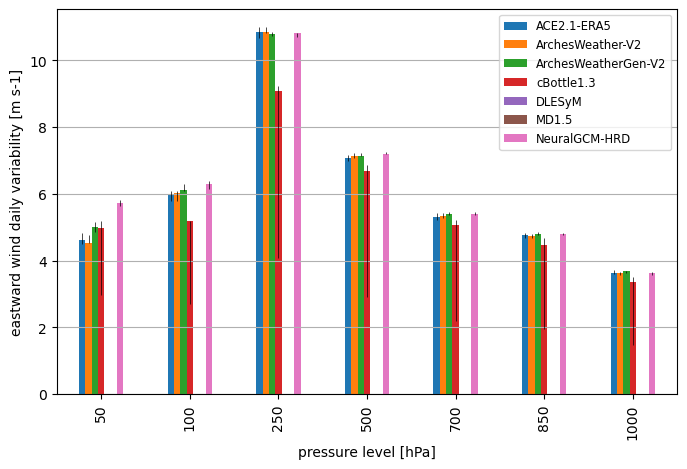

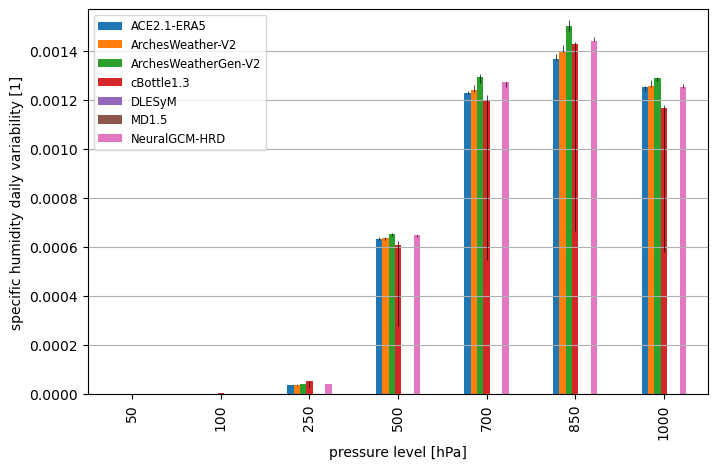

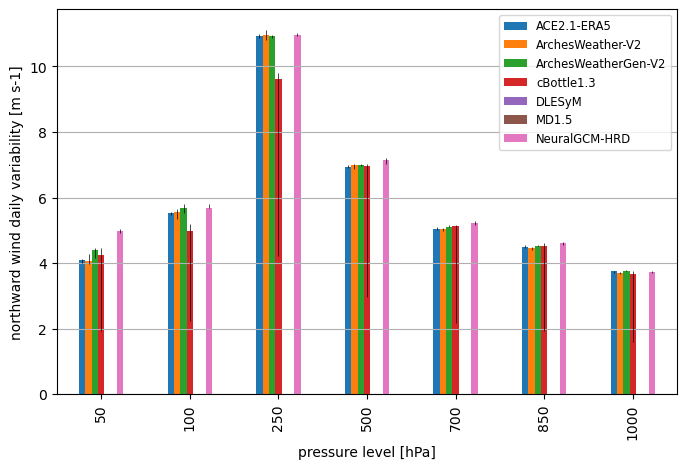

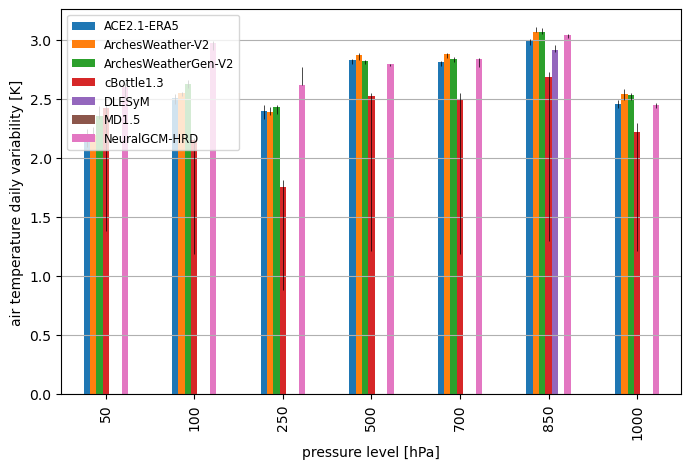

In [22]:
for varname in [varname for varname in means_1deg.data_vars if "plev" in means_1deg[varname].dims]:
    fig, ax = plt.subplots(figsize=(8, 5))
    means_1deg_var = means_1deg[varname].rename('Mean Std.').transpose('plev', 'experiment_submission', 'realization')
    lowest, median, highest = (
        means_1deg_var.min('realization').to_dataframe().unstack(),
        means_1deg_var.median('realization').to_dataframe().unstack(),
        means_1deg_var.max('realization').to_dataframe().unstack(),
    )
    median.plot.bar(
        ax=ax,
        legend=False,
        color=CATEGORICAL_COLORS,
        yerr=np.concat([(median - lowest).values.T[:, None, :], (highest - median).values.T[:, None, :]], axis=1),
        capsize=0,
        error_kw=dict(elinewidth=0.5),
    )
    ax.legend(means_1deg.experiment_submission.values, fontsize='small')
    ymax = median.max().mean() * 1.1
    ax.set_ylim([0, ymax])
    ax.set_xticklabels([str(round(ind/100)) for ind in median.index])
    ax.set_xlabel('pressure level [hPa]')
    ax.set_ylabel(f"{means_1deg[varname].attrs.get('long_name', varname)} [{means_1deg[varname].attrs.get('units', '-')}]")
    ax.grid(axis='y')
    fig.patch.set_alpha(0.0)
    fig.savefig(os.path.join(OUTDIR, f"daily_anomaly_std_1deg_mean_{varname}.png"), bbox_inches='tight')

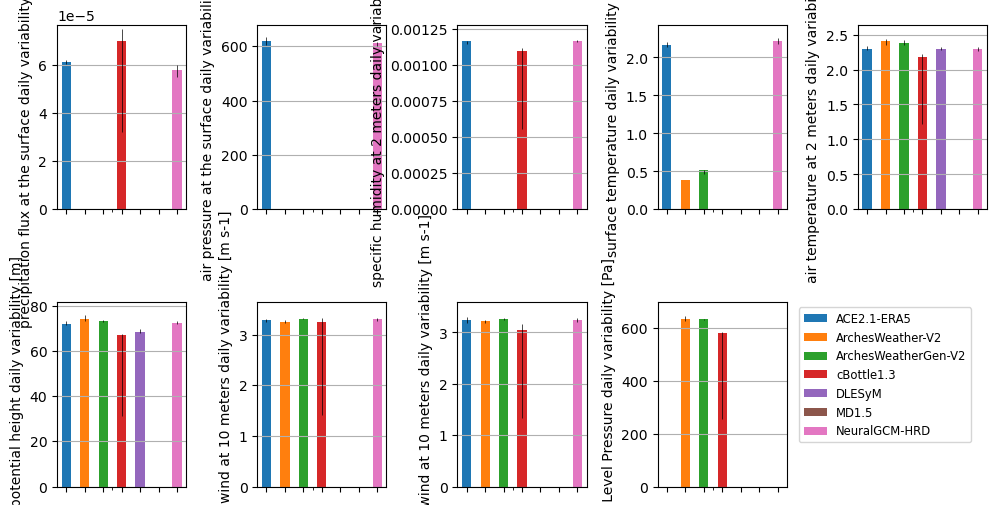

In [23]:
surface_vars = [var for var in means_1deg.data_vars if "plev" not in means_1deg[var].coords]
fig, axes = plt.subplots(ncols=int(np.ceil(len(surface_vars) / 2)), nrows=2, figsize=(12, 6), sharex=True, sharey=False, gridspec_kw={'wspace': 0.55, 'hspace': 0.5})
for ax, varname in zip(axes.flatten(), surface_vars):
    means_1deg_var = means_1deg[varname].transpose('experiment_submission', 'realization')
    lowest, median, highest = (
        means_1deg_var.min('realization').to_dataframe()[varname],
        means_1deg_var.median('realization').to_dataframe()[varname],
        means_1deg_var.max('realization').to_dataframe()[varname],
    )
    h = median.plot.bar(
        ax=ax,
        legend=False,
        color=CATEGORICAL_COLORS,
        yerr=np.concat([(median - lowest).values[None, :], (highest - median).values[None, :]], axis=0),
        capsize=0,
        error_kw=dict(elinewidth=0.5),
    )
    if ax is axes.flatten()[-2]:
        axes.flatten()[-1].set_axis_off()
        handles = [p for p in ax.patches]
        ax.legend(handles, means_1deg.experiment_submission.values, fontsize='small', bbox_to_anchor=(1.05, 1), loc='upper left')
    ymax = median.max() * 1.1
    ax.set_ylim([0, ymax])
    ax.set_xticklabels([])
    ax.set_xlabel('')
    ax.set_ylabel(f"{means_1deg[varname].attrs.get('long_name', varname)} [{means_1deg[varname].attrs.get('units', '-')}]")
    ax.grid(axis='y')
    fig.patch.set_alpha(0.0)
    fig.savefig(os.path.join(OUTDIR, f"daily_anomaly_std_1deg_mean_surface_variables.png"), bbox_inches='tight')

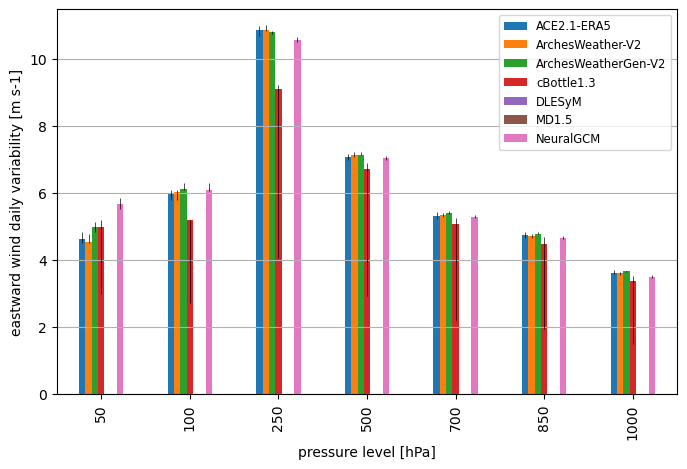

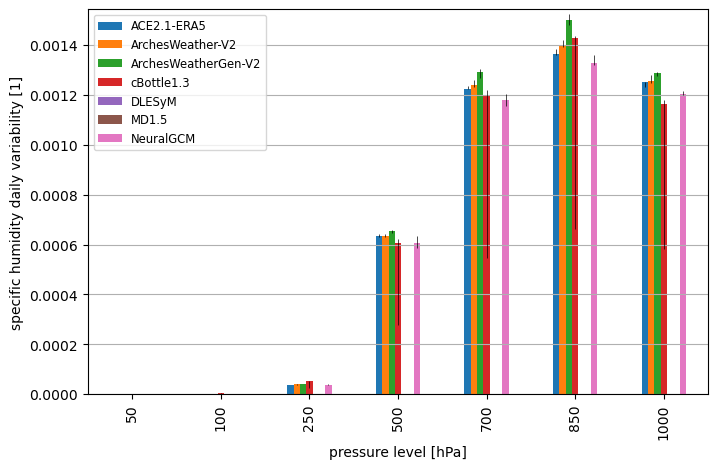

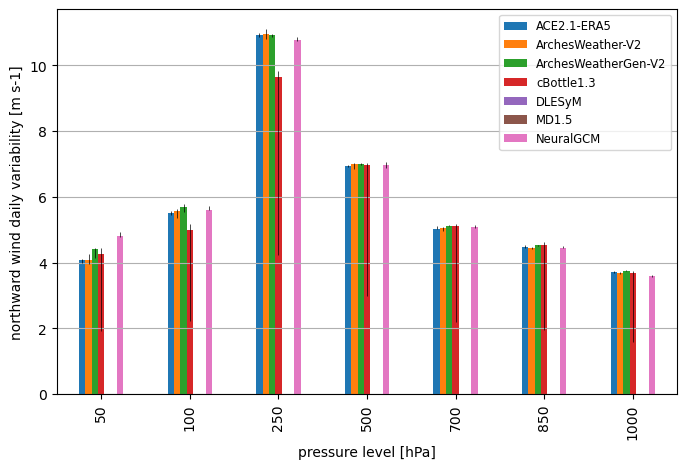

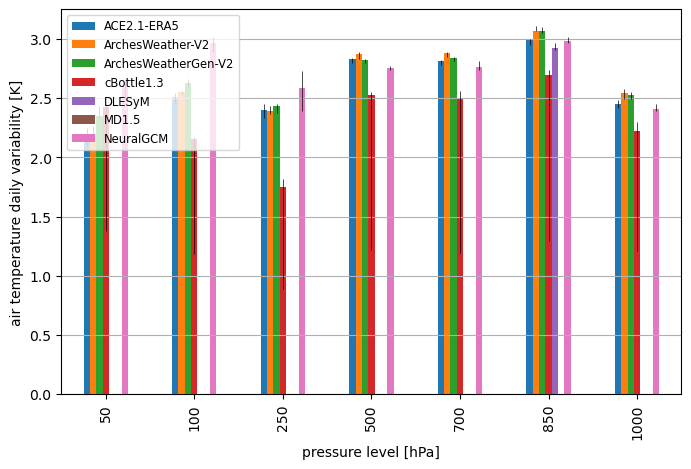

In [24]:
for varname in [varname for varname in means_2p8deg.data_vars if "plev" in means_2p8deg[varname].dims]:
    fig, ax = plt.subplots(figsize=(8, 5))
    means_2p8deg_var = means_2p8deg[varname].rename('Mean Std.').transpose('plev', 'experiment_submission', 'realization')
    lowest, median, highest = (
        means_2p8deg_var.min('realization').to_dataframe().unstack(),
        means_2p8deg_var.median('realization').to_dataframe().unstack(),
        means_2p8deg_var.max('realization').to_dataframe().unstack(),
    )
    median.plot.bar(
        ax=ax,
        legend=False,
        color=CATEGORICAL_COLORS,
        yerr=np.concat([(median - lowest).values.T[:, None, :], (highest - median).values.T[:, None, :]], axis=1),
        capsize=0,
        error_kw=dict(elinewidth=0.5),
    )
    ax.legend(means_2p8deg.experiment_submission.values, fontsize='small')
    ymax = median.max().mean() * 1.1
    ax.set_ylim([0, ymax])
    ax.set_xticklabels([str(round(ind/100)) for ind in median.index])
    ax.set_xlabel('pressure level [hPa]')
    ax.set_ylabel(f"{means_2p8deg[varname].attrs.get('long_name', varname)} [{means_2p8deg[varname].attrs.get('units', '-')}]")
    ax.grid(axis='y')
    fig.patch.set_alpha(0.0)
    fig.savefig(os.path.join(OUTDIR, f"daily_anomaly_std_2p8deg_mean_{varname}.png"), bbox_inches='tight')

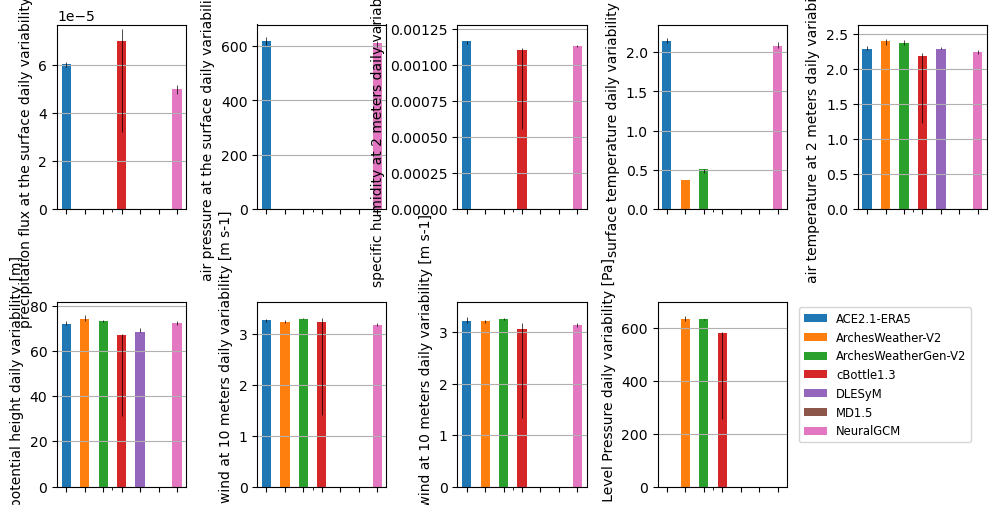

In [25]:
surface_vars = [var for var in means_2p8deg.data_vars if "plev" not in means_2p8deg[var].coords]
fig, axes = plt.subplots(ncols=int(np.ceil(len(surface_vars) / 2)), nrows=2, figsize=(12, 6), sharex=True, sharey=False, gridspec_kw={'wspace': 0.55, 'hspace': 0.5})
for ax, varname in zip(axes.flatten(), surface_vars):
    means_2p8deg_var = means_2p8deg[varname].transpose('experiment_submission', 'realization')
    lowest, median, highest = (
        means_2p8deg_var.min('realization').to_dataframe()[varname],
        means_2p8deg_var.median('realization').to_dataframe()[varname],
        means_2p8deg_var.max('realization').to_dataframe()[varname],
    )
    h = median.plot.bar(
        ax=ax,
        legend=False,
        color=CATEGORICAL_COLORS,
        yerr=np.concat([(median - lowest).values[None, :], (highest - median).values[None, :]], axis=0),
        capsize=0,
        error_kw=dict(elinewidth=0.5),
    )
    if ax is axes.flatten()[-2]:
        axes.flatten()[-1].set_axis_off()
        handles = [p for p in ax.patches]
        ax.legend(handles, means_2p8deg.experiment_submission.values, fontsize='small', bbox_to_anchor=(1.05, 1), loc='upper left')
    ymax = median.max() * 1.1
    ax.set_ylim([0, ymax])
    ax.set_xticklabels([])
    ax.set_xlabel('')
    ax.set_ylabel(f"{means_2p8deg[varname].attrs.get('long_name', varname)} [{means_2p8deg[varname].attrs.get('units', '-')}]")
    ax.grid(axis='y')
    fig.patch.set_alpha(0.0)
    fig.savefig(os.path.join(OUTDIR, f"daily_anomaly_std_2p8deg_mean_surface_variables.png"), bbox_inches='tight')